In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [16]:
image_path = "Images/regular_01.jpg"

In [17]:
def compute_circularity(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    if perimeter == 0:
        return 0

    circularity = 4 * np.pi * area / (perimeter ** 2)
    return circularity

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

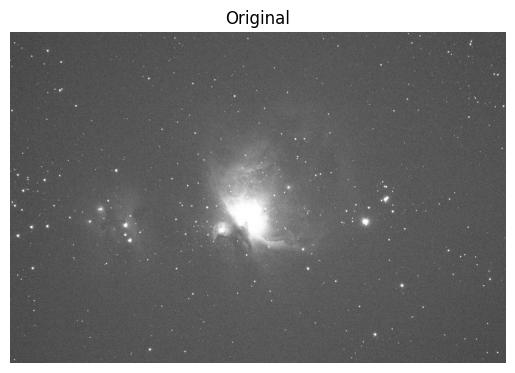

In [18]:
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

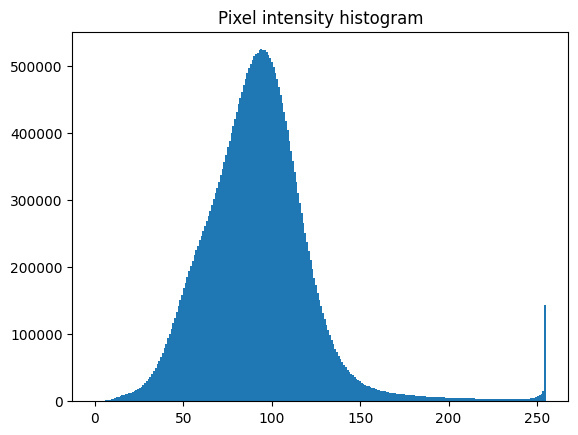

In [21]:
plt.hist(img.ravel(), bins=256)
plt.title("Pixel intensity histogram")
plt.show()

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

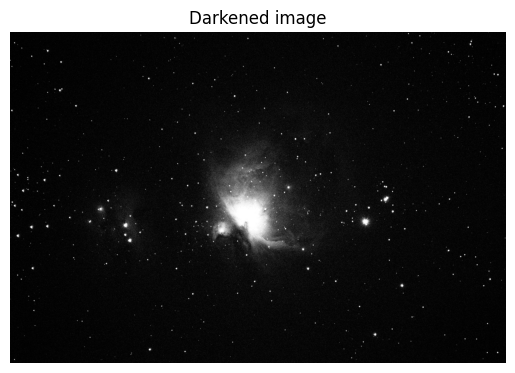

In [19]:
darkened = cv2.addWeighted(img, alpha=0.1, src2=np.zeros(img.shape, img.dtype), beta=0.3, gamma=-10)

plt.imshow(darkened, cmap="gray")
plt.title("Darkened image")
plt.axis("off")

C:\Users\manue\AppData\Local\Temp\ipykernel_89832\1919176586.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(darkened.ravel(),256,[0,256])


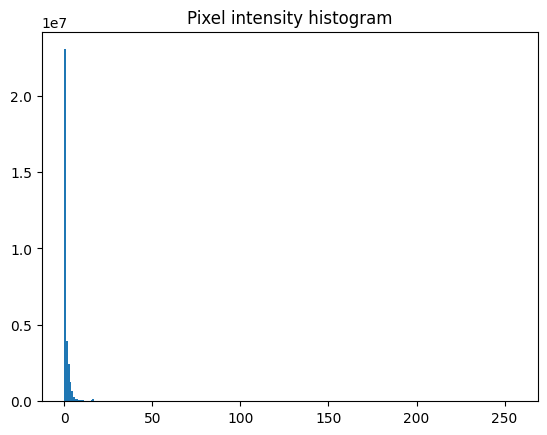

In [22]:
plt.hist(darkened.ravel(),256,[0,256])
plt.title("Pixel intensity histogram")
plt.show()

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

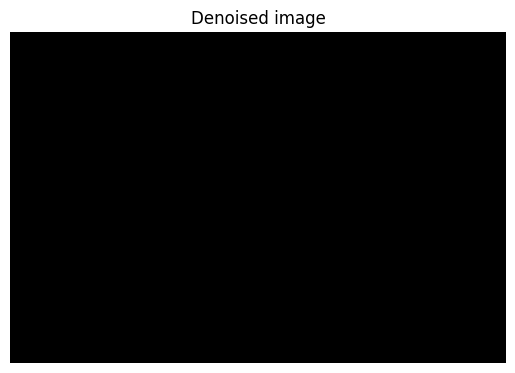

In [12]:
_, binary = cv2.threshold(darkened, 175, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap="gray")
plt.title("Denoised image")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

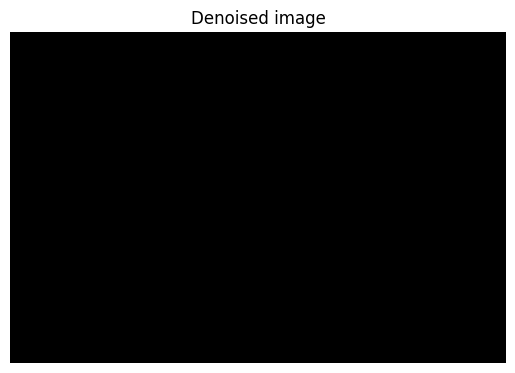

In [9]:
for i in range(len(darkened)):
    for j in range(len(darkened[i])):
        if darkened[i,j] < 200:
            darkened[i,j] = 0
        else:
            darkened[i,j] = 255

plt.imshow(darkened, cmap="gray")
plt.title("Denoised image")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

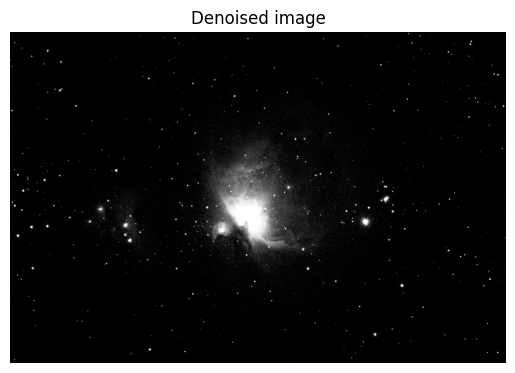

In [7]:
denoised = cv2.medianBlur(darkened, 5)
denoised = cv2.GaussianBlur(denoised, (5,5), 0)

plt.imshow(denoised, cmap="gray")
plt.title("Denoised image")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

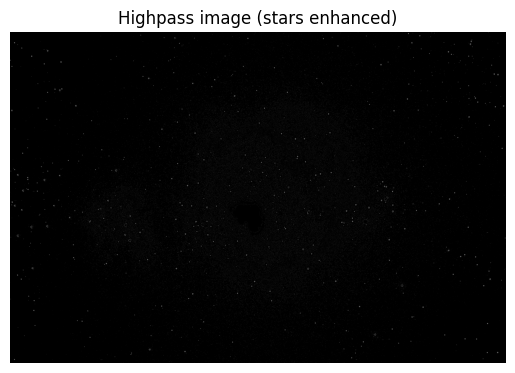

In [8]:
background = cv2.GaussianBlur(denoised, (31,31), 0)

stars = cv2.subtract(denoised, background)

plt.imshow(stars, cmap="gray")
plt.title("Highpass image (stars enhanced)")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

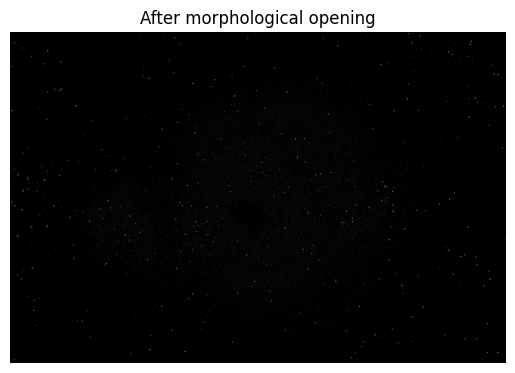

In [11]:
kernel = np.ones((3,3), np.uint8)

clean = cv2.morphologyEx(stars, cv2.MORPH_OPEN, kernel)

plt.imshow(clean, cmap="gray")
plt.title("After morphological opening")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

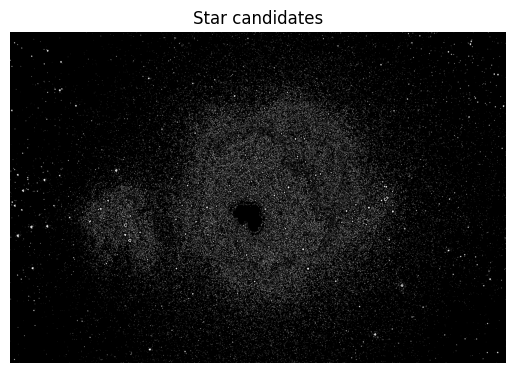

In [12]:
threshold = np.mean(clean) + 2*np.std(clean)

_, mask = cv2.threshold(clean, threshold, 255, cv2.THRESH_BINARY)

plt.imshow(mask, cmap="gray")
plt.title("Star candidates")
plt.axis("off")

In [36]:
min_area = 50
max_area = 120

In [37]:
# find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print("Contours detected:", len(contours))

Contours detected: 54949


In [38]:
valid = []

for c in contours:

    area = cv2.contourArea(c)

    if area < min_area or area > max_area:
        continue

    circ = compute_circularity(c)

    if circ < 0.6:
        continue

    """mask_blob = np.zeros_like(img)
    cv2.drawContours(mask_blob, [c], -1, 255, -1)

    mean_intensity = cv2.mean(img, mask=mask_blob)[0]

    if mean_intensity < 30:
        continue"""

    valid.append(c)

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

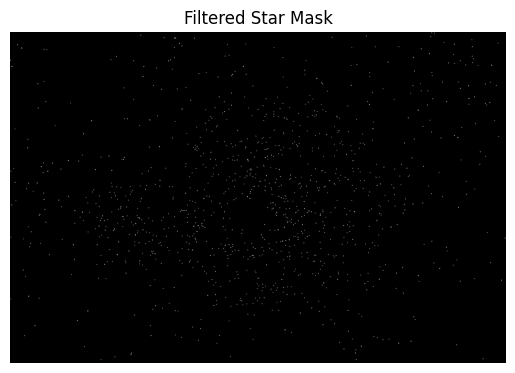

In [39]:
filtered_mask = np.zeros_like(mask)
cv2.drawContours(filtered_mask, valid, -1, 255, -1)

plt.imshow(filtered_mask, cmap="gray")
plt.title("Filtered Star Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

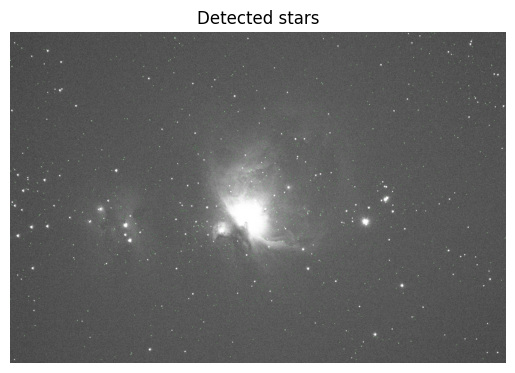

In [45]:
overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

cv2.drawContours(overlay, valid, -1, (0,255,0), 1)

plt.imshow(overlay)
plt.title("Detected stars")
plt.axis("off")

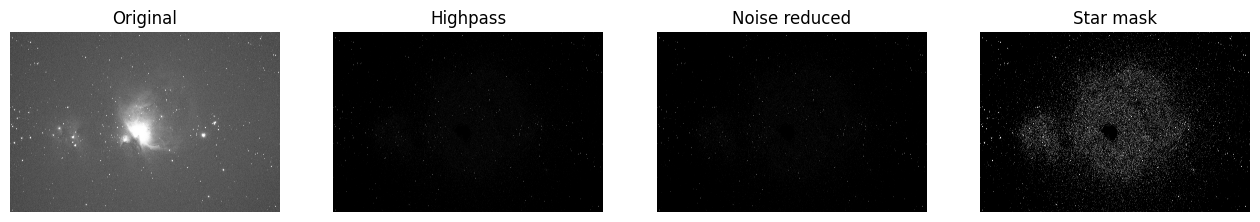

In [33]:
fig, ax = plt.subplots(1,4, figsize=(16,4))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(stars, cmap="gray")
ax[1].set_title("Highpass")

ax[2].imshow(clean, cmap="gray")
ax[2].set_title("Noise reduced")

ax[3].imshow(mask, cmap="gray")
ax[3].set_title("Star mask")

for a in ax:
    a.axis("off")

plt.show()